# Voorspellen van het wijntype met Deep Learning

<!-- Korte uitleg over wat deep learning doet -->
Deep learning wordt gebruikt om patronen te herkennen in data. In dit voorbeeld wordt de Wine Quality-dataset gebruikt. Dit is een dataset met gegevens over de samenstelling van wijn en de beoordeling van de kwaliteit.

<!-- Uitleg over wat het model leert -->
Het model kijkt naar verschillende eigenschappen van de wijn, zoals de hoeveelheid zuren, suiker, zoutachtige stoffen en zwaveldioxide. Op basis van deze gegevens leert het model om het wijntype of de kwaliteit van de wijn te voorspellen.

<!-- Voorbeelden van kenmerken uit de dataset -->
De dataset bestaat uit 12 kenmerken. Voorbeelden hiervan zijn:

- Fixed Acidity: zuren die zorgen voor een frisse of zure smaak.
- Volatile Acidity: azijnzuur, dat bij een hoge hoeveelheid een azijnachtige smaak kan geven.
- Citric Acid: citroenzuur dat invloed heeft op de frisheid.
- Residual Sugar: suiker die overblijft na het gistingsproces.
- Chlorides: stoffen die invloed kunnen hebben op een zoute smaak.
- Free Sulfur Dioxide: stof die helpt om wijn langer goed te houden.
- Total Sulfur Dioxide: de totale hoeveelheid van deze stof in de wijn.

## 1. Benodigde libraries importeren

<!-- Uitleg over welke libraries nodig zijn -->
Voor het bouwen van het model worden verschillende Python-libraries gebruikt. Deze libraries helpen bij het verwerken van data, het maken van grafieken en het bouwen van een deep learning-model.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Splitst de data in train- en testsets
from sklearn.model_selection import train_test_split

# Schaal de data zodat features vergelijkbaar worden
from sklearn.preprocessing import StandardScaler

# Meet extra prestaties naast accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Sequential bouwt een neural network laag voor laag op
from keras.models import Sequential

# Dense is een volledig verbonden neural-network-laag
# Input geeft duidelijk de vorm van de invoer aan
from keras.layers import Dense, Input

# Zorgt dat experimenten beter vergelijkbaar zijn
import tensorflow as tf

## 2. Data laden en voorbereiden

<!-- Uitleg over het laden van de datasets -->
In deze stap worden de datasets van rode en witte wijn ingeladen. Daarna worden ze voorbereid, zodat het model de data kan gebruiken om te trainen en voorspellingen te maken.

<!-- Uitleg over het verschil tussen rode en witte wijn -->
Er wordt een extra kolom type toegevoegd. Hiermee kan het model onderscheid maken tussen rode en witte wijn.

- type = 1 betekent rode wijn.
- type = 0 betekent witte wijn.

In [2]:
# Leest de rode en witte wijn-datasets in
red = pd.read_csv("redwinequality.csv", sep=";")
white = pd.read_csv("whitewinequality.csv", sep=";")

# Voegt een label toe: rood = 1, wit = 0
red["type"] = 1
white["type"] = 0

# Combineert beide datasets tot één DataFrame
wines = pd.concat([red, white], ignore_index=True)

# Verwijdert rijen met missende waarden
wines.dropna(inplace=True)

## 3. Verdeling van alcohol weergeven

<!-- Uitleg over het maken van de grafiek -->
In deze stap wordt met matplotlib een grafiek gemaakt. De grafiek laat zien hoe het alcoholpercentage verdeeld is bij rode en witte wijn.

<!-- Uitleg over histogrammen -->
Er worden twee histogrammen gemaakt: één voor rode wijn en één voor witte wijn. Een histogram laat zien hoe vaak bepaalde waarden voorkomen. In dit geval gaat het om het alcoholpercentage.

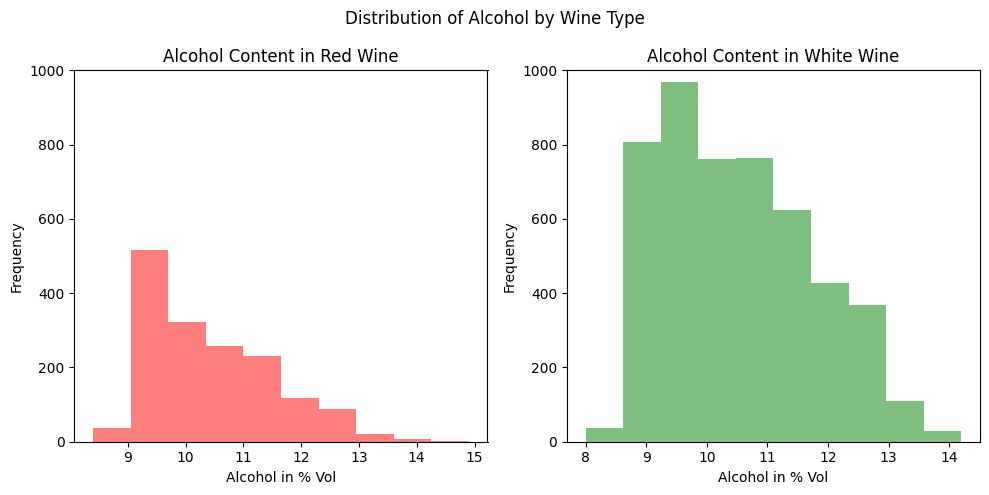

In [3]:
# Maakt twee grafieken naast elkaar
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Histogram van alcoholpercentage bij rode wijn
ax[0].hist(
    wines[wines["type"] == 1].alcohol,
    bins=10,
    facecolor="red",
    alpha=0.5,
    label="Red wine"
)

# Histogram van alcoholpercentage bij witte wijn
ax[1].hist(
    wines[wines["type"] == 0].alcohol,
    bins=10,
    facecolor="green",
    lw=0.5,
    alpha=0.5,
    label="White wine"
)

# Geeft beide grafieken dezelfde assenlabels en schaal
for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel("Alcohol in % Vol")
    a.set_ylabel("Frequency")

ax[0].set_title("Alcohol Content in Red Wine")
ax[1].set_title("Alcohol Content in White Wine")

# Algemene titel voor de volledige figuur
fig.suptitle("Distribution of Alcohol by Wine Type")
plt.tight_layout()
plt.show()

## 4. Data verdelen in training en test

<!-- Uitleg over het verdelen van de data -->
In deze stap wordt de dataset verdeeld in twee delen: trainingsdata en testdata.

<!-- Uitleg over trainingsdata en testdata -->
De trainingsdata wordt gebruikt om het model te leren. De testdata wordt daarna gebruikt om te controleren hoe goed het model voorspellingen kan maken met nieuwe data.


In [4]:
# X bevat alle input-features behalve het wijn-type
X = wines.iloc[:, :-1]

# y bevat het target-label: rood = 1, wit = 0
y = wines["type"]

# Splitst de data in trainingsdata en testdata
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.34,
    random_state=45
)

## 5. Neuraal netwerkmodel maken

<!-- Uitleg over het model -->
In deze stap wordt een neuraal netwerk gemaakt. Dit is het model dat leert om rode en witte wijn van elkaar te onderscheiden.

<!-- Uitleg over de lagen -->
Het model bestaat uit 3 lagen:

- Input layer: de eerste laag ontvangt de gegevens van de wijn.
- Hidden layer: deze laag zoekt naar patronen in de gegevens.
- Output layer: deze laag geeft de voorspelling: rode wijn of witte wijn.


In [5]:
# Sequential voert de lagen één voor één uit
model = Sequential()

# Input layer: gebruikt automatisch het aantal input-features
model.add(Input(shape=(X_train.shape[1],)))

# Hidden layer: leert patronen uit de input-features
# ReLU laat positieve waarden door en zet negatieve waarden op 0
model.add(Dense(12, activation="relu"))

# Tweede hidden layer: leert diepere patronen uit de vorige laag
model.add(Dense(9, activation="relu"))

# Output layer: geeft één voorspelling voor rood of wit
# Sigmoid zet de uitkomst om naar een kans tussen 0 en 1
model.add(Dense(1, activation="sigmoid"))

# Compile stelt in hoe het model leert en hoe prestaties worden gemeten
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

## 6. Model trainen

<!-- Uitleg over het trainen van het model -->
In deze stap wordt het model getraind met de trainingsdata. Tijdens het trainen leert het model patronen herkennen in de gegevens van rode en witte wijn.

In [6]:
# Traint het neural network met de trainingsdata
# epochs=3 betekent dat het model 3 keer door alle trainingsdata gaat
# batch_size=1 betekent dat de gewichten na elk voorbeeld worden bijgewerkt
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step - accuracy: 0.9107 - loss: 0.5812
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9433 - loss: 0.1654
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.9541 - loss: 0.1387


## 7. Voorspellingen maken

<!-- Uitleg over het maken van voorspellingen -->
In deze stap gebruikt het getrainde model de testdata om voorspellingen te maken. Het model voorspelt of een wijn rood of wit is.

<!-- Uitleg over de uitkomst -->
Het model geeft eerst een kanswaarde. Daarna wordt deze kans omgezet naar een duidelijke uitkomst:

- 1 betekent rode wijn.
- 0 betekent witte wijn.

In [7]:
# Maakt voorspellingen op de testdata
y_pred = model.predict(X_test, verbose=0)

# Zet kanswaarden om naar labels: groter dan 0.5 = rood, anders wit
y_pred_labels = (y_pred > 0.5).astype(int).flatten()

# Vergelijkt de eerste 12 voorspellingen met de echte labels
for predicted, actual in zip(y_pred_labels[:12], y_test.iloc[:12]):
    predicted_type = "Red wine" if predicted == 1 else "White wine"
    actual_type = "Red wine" if actual == 1 else "White wine"

    result = "Goed" if predicted == actual else "Fout"

    print(f"Voorspeld: {predicted_type} | Echt: {actual_type} | {result}")

# Berekent de totale score op de testset
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: Red wine | Echt: Red wine | Goed
Voorspeld: Red wine | Echt: Red wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: Red wine | Echt: Red wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Voorspeld: White wine | Echt: White wine | Goed
Loss: 0.1035
Accuracy: 0.9642


## 8. Extra experimenten uitvoeren

<!-- Uitleg over experimenten -->
Om te onderzoeken welke instellingen het beste werken, worden meerdere experimenten uitgevoerd. Elk experiment gebruikt andere instellingen, zoals het aantal epochs, batch size, optimizer, aantal neuronen en wel of geen standaardisatie.

<!-- Waarom dit belangrijk is -->
Door de resultaten in één tabel te zetten, kun je makkelijk vergelijken welk model het beste presteert. Hierbij wordt niet alleen naar accuracy gekeken, maar ook naar precision, recall en F1-score.

In [8]:
# Functie om snel verschillende neural networks te bouwen

def bouw_model(input_dim, hidden_layers=(12, 9), optimizer="adam", activation="relu"):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )

    return model

In [9]:
# Overzicht van de experimenten die worden getest
# Je kunt hier makkelijk extra experimenten aan toevoegen

experimenten = [
    {
        "Experiment": "Baseline",
        "Hidden layers": (12, 9),
        "Epochs": 3,
        "Batch size": 1,
        "Optimizer": "adam",
        "Standaardisatie": "Nee"
    },
    {
        "Experiment": "Meer epochs",
        "Hidden layers": (12, 9),
        "Epochs": 10,
        "Batch size": 8,
        "Optimizer": "adam",
        "Standaardisatie": "Nee"
    },
    {
        "Experiment": "Grotere batch size",
        "Hidden layers": (12, 9),
        "Epochs": 10,
        "Batch size": 32,
        "Optimizer": "adam",
        "Standaardisatie": "Nee"
    },
    {
        "Experiment": "Kleiner model",
        "Hidden layers": (8,),
        "Epochs": 10,
        "Batch size": 16,
        "Optimizer": "adam",
        "Standaardisatie": "Nee"
    },
    {
        "Experiment": "Groter model",
        "Hidden layers": (32, 16, 8),
        "Epochs": 10,
        "Batch size": 16,
        "Optimizer": "adam",
        "Standaardisatie": "Nee"
    },
    {
        "Experiment": "Met standaardisatie",
        "Hidden layers": (12, 9),
        "Epochs": 10,
        "Batch size": 16,
        "Optimizer": "adam",
        "Standaardisatie": "Ja"
    },
    {
        "Experiment": "Andere optimizer",
        "Hidden layers": (20, 15),
        "Epochs": 10,
        "Batch size": 16,
        "Optimizer": "rmsprop",
        "Standaardisatie": "Ja"
    }
]

In [10]:
# Draait alle experimenten en zet de resultaten in een overzichtelijke tabel

resultaten = []

for nummer, experiment in enumerate(experimenten, start=1):
    print(f"Experiment {nummer}/{len(experimenten)}: {experiment['Experiment']}")

    # Zet random seeds zodat de vergelijking eerlijker en stabieler is
    np.random.seed(45)
    tf.random.set_seed(45)

    # Zelfde train/test split voor elk experiment
    X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
        X,
        y,
        test_size=0.34,
        random_state=45
    )

    # Optioneel standaardiseren
    if experiment["Standaardisatie"] == "Ja":
        scaler = StandardScaler()
        X_train_exp = scaler.fit_transform(X_train_exp)
        X_test_exp = scaler.transform(X_test_exp)
    else:
        X_train_exp = X_train_exp.values
        X_test_exp = X_test_exp.values

    # Model bouwen en trainen
    exp_model = bouw_model(
        input_dim=X_train_exp.shape[1],
        hidden_layers=experiment["Hidden layers"],
        optimizer=experiment["Optimizer"]
    )

    exp_model.fit(
        X_train_exp,
        y_train_exp,
        epochs=experiment["Epochs"],
        batch_size=experiment["Batch size"],
        verbose=0
    )

    # Model evalueren
    loss, accuracy = exp_model.evaluate(X_test_exp, y_test_exp, verbose=0)
    y_pred_exp = exp_model.predict(X_test_exp, verbose=0)
    y_pred_labels_exp = (y_pred_exp > 0.5).astype(int).flatten()

    resultaten.append({
        "Experiment": experiment["Experiment"],
        "Hidden layers": str(experiment["Hidden layers"]),
        "Epochs": experiment["Epochs"],
        "Batch size": experiment["Batch size"],
        "Optimizer": experiment["Optimizer"],
        "Standaardisatie": experiment["Standaardisatie"],
        "Loss": round(loss, 4),
        "Accuracy": round(accuracy_score(y_test_exp, y_pred_labels_exp), 4),
        "Precision": round(precision_score(y_test_exp, y_pred_labels_exp), 4),
        "Recall": round(recall_score(y_test_exp, y_pred_labels_exp), 4),
        "F1-score": round(f1_score(y_test_exp, y_pred_labels_exp), 4)
    })

resultaten_df = pd.DataFrame(resultaten)
resultaten_df = resultaten_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

# Toont de resultaten als overzichtelijke tabel
resultaten_df

Experiment 1/7: Baseline
Experiment 2/7: Meer epochs
Experiment 3/7: Grotere batch size
Experiment 4/7: Kleiner model
Experiment 5/7: Groter model
Experiment 6/7: Met standaardisatie
Experiment 7/7: Andere optimizer


,Experiment,Hidden layers,Epochs,Batch size,Optimizer,Standaardisatie,Loss,Accuracy,Precision,Recall,F1-score
0,Andere optimizer,"(20, 15)",10,16,rmsprop,Ja,0.0475,0.9932,0.9877,0.9859,0.9868
1,Met standaardisatie,"(12, 9)",10,16,adam,Ja,0.0424,0.9919,0.9842,0.9842,0.9842
2,Groter model,"(32, 16, 8)",10,16,adam,Nee,0.0898,0.9710,0.9667,0.9190,0.9422
3,Kleiner model,"(8,)",10,16,adam,Nee,0.1169,0.9638,0.9692,0.8873,0.9265
4,Meer epochs,"(12, 9)",10,8,adam,Nee,0.1032,0.9606,0.9744,0.8697,0.9191
5,Baseline,"(12, 9)",3,1,adam,Nee,0.1330,0.9543,0.9587,0.8592,0.9062
6,Grotere batch size,"(12, 9)",10,32,adam,Nee,0.1595,0.9430,0.9604,0.8116,0.8798


## 9. Beste experiment en conclusie

<!-- Uitleg over de conclusie -->
Na het draaien van de experimenten wordt het beste experiment automatisch geselecteerd op basis van accuracy. De F1-score is ook belangrijk, omdat die precision en recall combineert.

In [11]:
# Selecteert het beste experiment uit de tabel
beste_experiment = resultaten_df.iloc[0]

print("Beste experiment:")
print(f"Naam: {beste_experiment['Experiment']}")
print(f"Accuracy: {beste_experiment['Accuracy']}")
print(f"F1-score: {beste_experiment['F1-score']}")
print(f"Instellingen: hidden layers={beste_experiment['Hidden layers']}, "
      f"epochs={beste_experiment['Epochs']}, "
      f"batch size={beste_experiment['Batch size']}, "
      f"optimizer={beste_experiment['Optimizer']}, "
      f"standaardisatie={beste_experiment['Standaardisatie']}")

Beste experiment:
Naam: Andere optimizer
Accuracy: 0.9932
F1-score: 0.9868
Instellingen: hidden layers=(20, 15), epochs=10, batch size=16, optimizer=rmsprop, standaardisatie=Ja


### Korte conclusie

Uit de experimententabel kun je aflezen welk model het beste werkt. Het beste model is het experiment met de hoogste accuracy. Wanneer twee modellen ongeveer dezelfde accuracy hebben, is de F1-score handig om te bepalen welk model stabieler presteert.

Meestal zorgt standaardisatie voor betere resultaten bij neural networks, omdat alle input-features dan op een vergelijkbare schaal staan. Ook kan een groter model beter presteren, maar dat is niet altijd zo: een te groot model kan ook overfitten.